### Facebook Artist Page Network (2017)

This notebook includes a comprehensive analysis of a Facebook artist pages network, sourced from the Network Data Repository (Rossi & Ahmed, 2015). The dataset was originally introduced by Rozemberczki et al. (2019) and consists of 819,096 connections between 50,492 nodes. It is represented as an edge list where each row is a mutual like between two artists. This setup provides a structured view of the global music industry on Facebook, potentially revealing community formations, an artist's influence within clusters, and more. The notebook attempts to identify and reveal such structures by applying a series of graph analytics functions from the igraph package in R, accompanied by visual representations of the extracted data.

List of igraph functions used in this notebook:

- `graph_from_data_frame()`
- `vcount()`
- `ecount()`
- `edge_density()`
- `degree()`
- `delete_vertices()`
- `coreness()`
- `eigen_centrality()`
- `page_rank()`
- `assortativity_degree()`
- `cluster_louvain()`
- `hits_scores()`
- `constraint()`
- `edge_connectivity()`
- `bridges()`
- `vertex_connectivity()`
- `mean_distance()`
- `diameter()`
- `betweenness()`
- `similarity()`

### Improting packages

In [2]:
# Importing libarires 

library("igraph")


Attaching package: 'igraph'


The following objects are masked from 'package:stats':

    decompose, spectrum


The following object is masked from 'package:base':

    union




### Reading input files
The dataset is loaded from two files - an edge list and a node list. The node identifiers are aligned with the edge list using the `new_id` column, and 23 edges referencing unlisted nodes are removed to ensure consistency. The graph is then constructed as an undirected network using igraph's `graph_from_data_frame()`, with artist names attached as node labels.

In [3]:
# Reading the graph from the file into an edge list
edges <- read.csv("./data/fb-pages-artist.edges", header = FALSE, col.names = c("from", "to"))
nodes <- read.csv("./data/fb-pages-artist.nodes", header = TRUE)

nodes$new_id <- as.character(nodes$new_id)
edges$from <- as.character(edges$from)
edges$to <- as.character(edges$to)

# Removing edges where either endpoint is missing from nodes
valid_ids <- nodes$new_id
edges <- edges[edges$from %in% valid_ids & edges$to %in% valid_ids,]

# Creating the graph from the edge list
g <- graph_from_data_frame(edges, directed = FALSE, vertices = nodes[, c("new_id", "name")])


### Graph properties

In [4]:
cat("Vertices:", vcount(g), "\n")
cat("Edges:", ecount(g), "\n")
cat("Density:", format(edge_density(g), scientific = FALSE), "\n")
cat("Maximum degree:", max(degree(g)), "\n")
cat("Average degree:", round(mean(degree(g)), 2), "\n")
cat("Minimum degree:", min(degree(g)), "\n")

Vertices: 50492 
Edges: 819096 
Density: 0.0006425816 
Maximum degree: 1468 
Average degree: 32.44 
Minimum degree: 1 


### Simpyfing the graph
Vertices with fewer than 1000 connections are removed to reduce noise and narrow down the analysis to the most connected artist pages, while also reducing the execution time of plots displaying the entire network. The resulting vertex and edge counts are printed to reflect the simplified graph.

In [5]:
# removing vertices with degree less than 1000

g <- delete_vertices(g, V(g)[degree(g) < 1000])
cat("\nVertices (post degree filtering):", vcount(g),"\nEdges (post degree filtering):", ecount(g), "\n")


Vertices (post degree filtering): 23 
Edges (post degree filtering): 80 


### Running igraph functions
In this section 10 graph analysis functions from the igraph package are applied. Assortativity degree measures whether highly connected artists tend to connect with other highly connected artists. Mean distance and diameter describe the average and maximum shortest paths across the network. Hub and authority scores identify nodes that link to many important pages versus nodes linked to by many hubs. Burt's constraint reveals artists that bridge otherwise disconnected communities by measuring structural gaps in their neighborhoods. Edge connectivity determines the minimum number of edges whose removal would disconnect the graph, while bridges identifies the specific critical edges. Vertex connectivity does the same for nodes. Jaccard similarity measures how much neighborhood overlap exists between pairs of artists. Betweenness centrality identifies artists that act as the most critical connectors across the network.

In [ ]:
g.assort <- assortativity_degree(g)
cat("Assortativity:", g.assort, "\n")
cat("Interpretation: values close to 0 indicate random mixing,",
    "positive = hubs connect to hubs, negative = hubs connect to periphery\n")

In [ ]:
cat("Average path length:", mean_distance(g), "\n")

In [ ]:
cat("Diameter:", diameter(g), "\n")

g.diam <- get_diameter(g)
edge_cols <- rep("gray80", ecount(g))
V(g)$color <- "lightblue"
V(g)[g.diam]$color <- "orange"
diam_edges <- get.edge.ids(g, as.vector(rbind(g.diam[-length(g.diam)], g.diam[-1])))
edge_cols[diam_edges] <- "red"

plot(g,
     vertex.color = V(g)$color,
     vertex.size  = 7,
     vertex.label = NA,
     edge.color   = edge_cols,
     edge.width   = ifelse(edge_cols == "red", 3, 0.8),
     main         = paste0("Diameter = ", diameter(g), "\n(orange nodes + red edges = longest shortest path)"))

Top 10 Hub scores:
              name       hub
       Yuna Alvara 1.0000000
    Jonny Zywiciel 0.8837634
    Christin Stark 0.8837634
          PLASTIKO 0.6803391
          Skrillex 0.4920397
      David Guetta 0.4797322
            Eminem 0.4349685
      Taylor Swift 0.4278859
     Justin Bieber 0.4278859
 Justin Timberlake 0.4278859
Top 10 Authority scores:
           name authority
    Yuna Alvara 1.0000000
 Christin Stark 0.8837634
 Jonny Zywiciel 0.8837634
       PLASTIKO 0.6803391
       Skrillex 0.4920397
   David Guetta 0.4797322
         Eminem 0.4349685
   Taylor Swift 0.4278859
  Justin Bieber 0.4278859
        Beyoncé 0.4278859


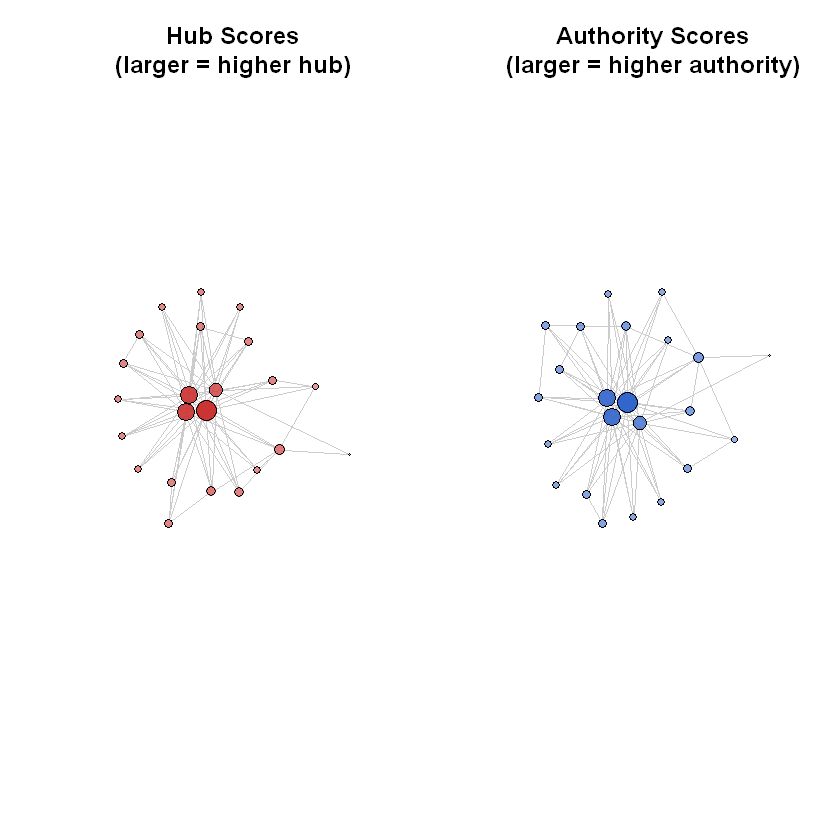

In [17]:
node_names <- V(g)$name

# normalizing a vector to [0,1] for visual scaling
norm01 <- function(x) {
  r <- range(x, na.rm = TRUE)
  if (diff(r) == 0) return(rep(0.5, length(x)))
  (x - r[1]) / diff(r)
}

g.hits   <- hits_scores(g)
hub_df   <- data.frame(name = node_names, hub       = g.hits$hub)
auth_df  <- data.frame(name = node_names, authority = g.hits$authority)
hub_df   <- hub_df[order(hub_df$hub,             decreasing = TRUE), ]
auth_df  <- auth_df[order(auth_df$authority,     decreasing = TRUE), ]
cat("Top 10 Hub scores:\n");       print(head(hub_df,  10), row.names = FALSE)
cat("Top 10 Authority scores:\n"); print(head(auth_df, 10), row.names = FALSE)

# Plot: side-by-side hub vs authority (node size = score)
par(mfrow = c(1, 2), bg = "white")
plot(g,
     vertex.size  = 3 + 15 * norm01(g.hits$hub),
     vertex.color = rgb(0.8, 0.2, 0.2,
                        alpha = 0.4 + 0.6 * norm01(g.hits$hub)),
     vertex.label = NA,
     edge.color   = "gray80",
     main         = "Hub Scores\n(larger = higher hub)")
plot(g,
     vertex.size  = 3 + 15 * norm01(g.hits$authority),
     vertex.color = rgb(0.2, 0.4, 0.8,
                        alpha = 0.4 + 0.6 * norm01(g.hits$authority)),
     vertex.label = NA,
     edge.color   = "gray80",
     main         = "Authority Scores\n(larger = higher authority)")
par(mfrow = c(1, 1))

Top 10 least constrained (structural hole bridgers):
            name constraint
        PLASTIKO 0.07329102
  Christin Stark 0.14355453
  Jonny Zywiciel 0.14355453
     Yuna Alvara 0.18478661
        Skrillex 0.24397184
    David Guetta 0.26500064
          Eminem 0.26549599
         Rihanna 0.27431119
      Katy Perry 0.27747299
 Michael Jackson 0.27747299


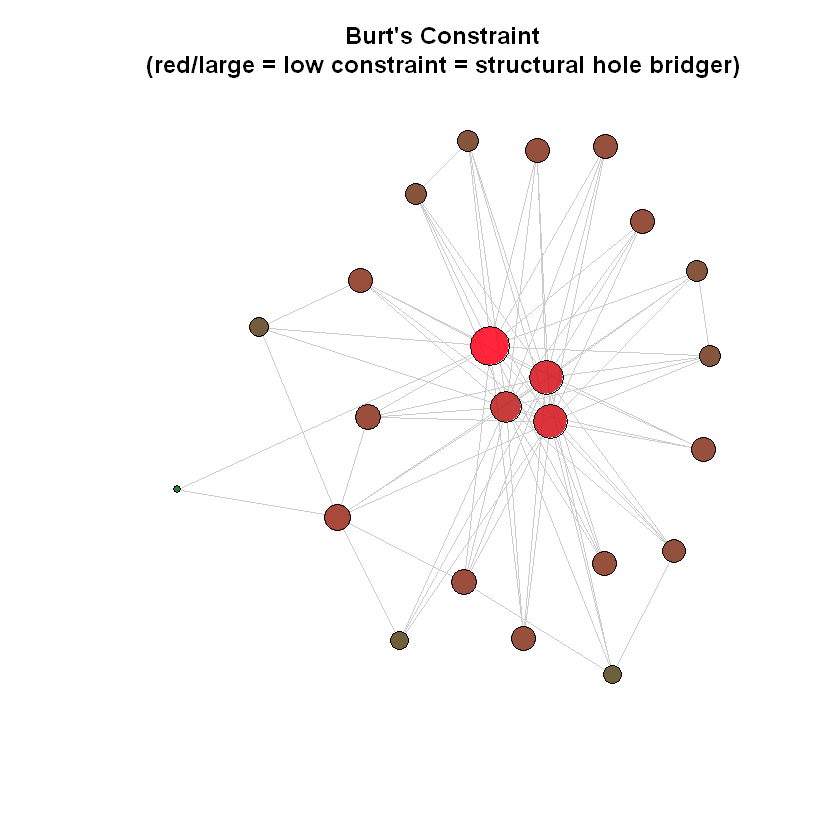

In [18]:
g.constraint <- constraint(g)
const_df <- data.frame(name = node_names, constraint = g.constraint)
const_df <- const_df[order(const_df$constraint, na.last = TRUE), ]
cat("Top 10 least constrained (structural hole bridgers):\n")
print(head(const_df, 10), row.names = FALSE)

# Plot: low constraint (red) = bridging nodes = structural power
constraint_safe <- ifelse(is.na(g.constraint), 1, g.constraint)
plot(g,
     vertex.size  = 3 + 12 * (1 - norm01(constraint_safe)),
     vertex.color = rgb(1 - norm01(constraint_safe),
                        norm01(constraint_safe) * 0.4,
                        0.1, alpha = 0.85),
     vertex.label = NA,
     edge.color   = "gray80",
     main         = "Burt's Constraint\n(red/large = low constraint = structural hole bridger)",
     bg           = "white")

Edge connectivity: 2 - need to remove 2 edge(s) to disconnect


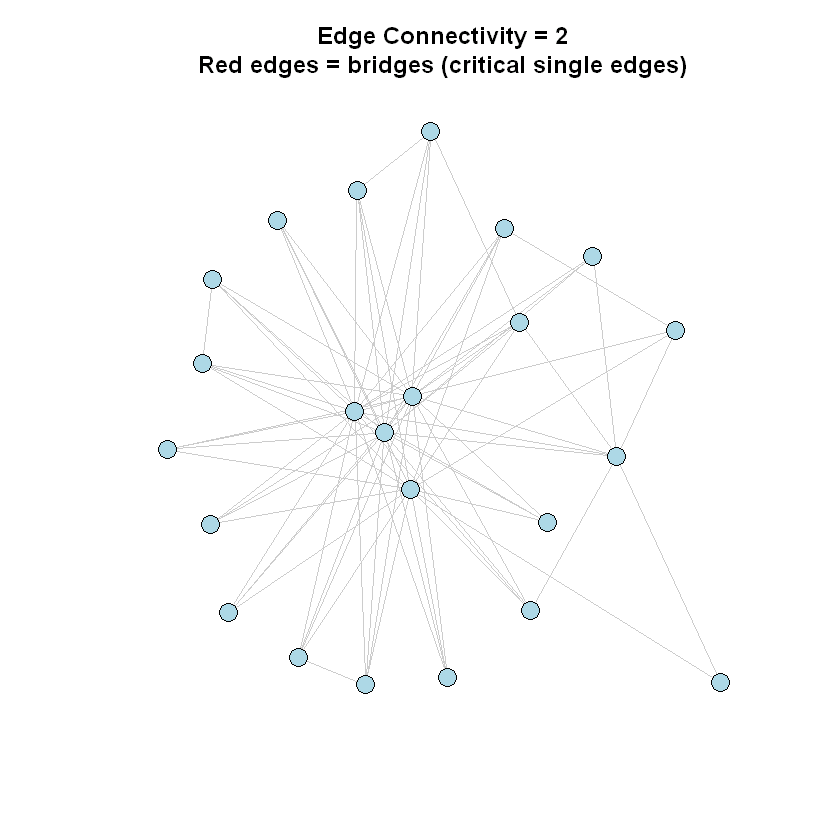

In [21]:
g.adhesion <- edge_connectivity(g)
cat("Edge connectivity:", g.adhesion,
    "- need to remove", g.adhesion, "edge(s) to disconnect\n")

g.bridges <- bridges(g)
edge_cols  <- rep("gray80", ecount(g))
edge_widths <- rep(0.8,     ecount(g))
if (length(g.bridges) > 0) {
  edge_cols[g.bridges]   <- "red"
  edge_widths[g.bridges] <- 3
}
plot(g,
     vertex.size  = 7,
     vertex.color = "lightblue",
     vertex.label = NA,
     edge.color   = edge_cols,
     edge.width   = edge_widths,
     main         = paste0("Edge Connectivity = ", g.adhesion,
                            "\nRed edges = bridges (critical single edges)"),
     bg           = "white")

Vertex connectivity: 2 — need to remove 2 node(s) to disconnect


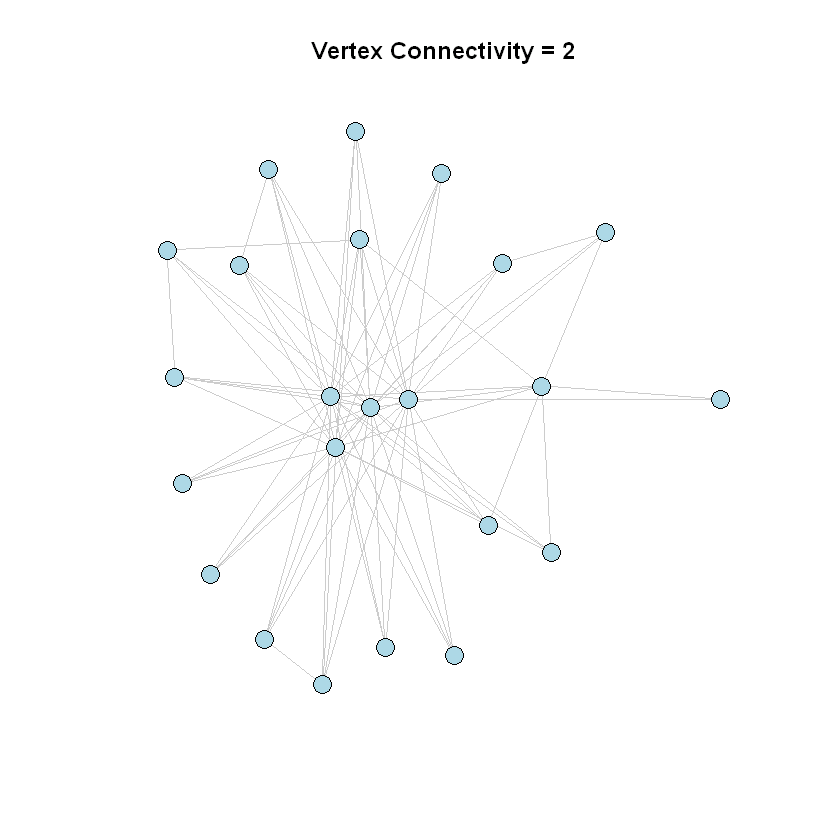

In [27]:
g.cohesion <- vertex_connectivity(g)
cat("Vertex connectivity:", g.cohesion,
    "— need to remove", g.cohesion, "node(s) to disconnect\n")

g.ap <- articulation_points(g)
V(g)$color <- "lightblue"
if (length(g.ap) > 0) V(g)[g.ap]$color <- "red"

plot(g,
     vertex.color = V(g)$color,
     vertex.size  = 7,
     vertex.label = NA,
     edge.color   = "gray80",
     main         = paste0("Vertex Connectivity = ", g.cohesion
     ),
     bg           = "white")

In [28]:
cat("Average path length:", mean_distance(g), "\n")
cat("Diameter:", diameter(g), "\n")

Average path length: 1.6917 
Diameter: 3 


In [24]:
g.sim <- similarity(g, method = "jaccard")
sim_pairs <- which(upper.tri(g.sim), arr.ind = TRUE)
sim_vals  <- g.sim[upper.tri(g.sim)]
sim_df <- data.frame(
  artist1     = node_names[sim_pairs[, 1]],
  artist2     = node_names[sim_pairs[, 2]],
  jaccard     = sim_vals
)
sim_df <- sim_df[order(sim_df$jaccard, decreasing = TRUE), ]
cat("Top 10 most similar artist pairs:\n")
print(head(sim_df, 10), row.names = FALSE)

Top 10 most similar artist pairs:
         artist1         artist2 jaccard
  Christin Stark  Jonny Zywiciel       1
      Katy Perry Michael Jackson       1
      Katy Perry       Lady Gaga       1
 Michael Jackson       Lady Gaga       1
      Katy Perry       Radiohead       1
 Michael Jackson       Radiohead       1
       Lady Gaga       Radiohead       1
      Katy Perry           Adele       1
 Michael Jackson           Adele       1
       Lady Gaga           Adele       1


Top 10 by betweenness centrality:
           name betweenness
    Yuna Alvara  44.0247045
       PLASTIKO  42.1500000
 Christin Stark  35.6145390
 Jonny Zywiciel  35.6145390
       Skrillex   8.8406619
   David Guetta   1.6835191
       Hardwell   0.9955758
        Rihanna   0.9955758
  Calvin Harris   0.6092199
         Eminem   0.6001857


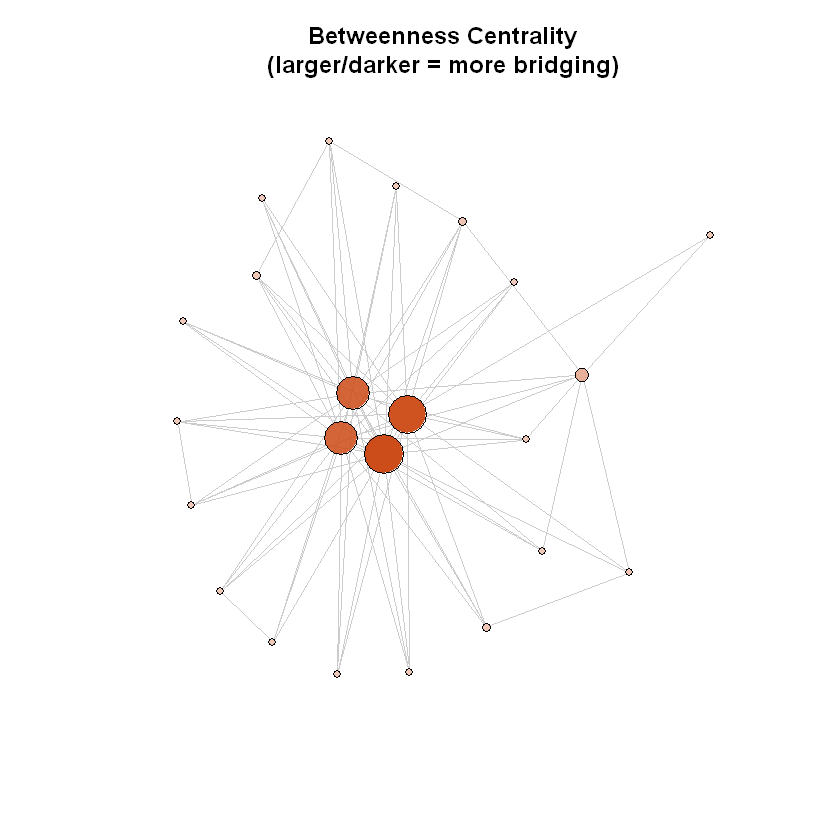

In [ ]:
g.betweenness <- betweenness(g)
bet_df <- data.frame(name = node_names, betweenness = g.betweenness)
bet_df <- bet_df[order(bet_df$betweenness, decreasing = TRUE), ]
cat("Top 10 by betweenness centrality:\n")
print(head(bet_df, 10), row.names = FALSE)

plot(g,
     vertex.size  = 3 + 12 * norm01(g.betweenness),
     vertex.color = rgb(0.8, 0.3, 0.1,
                        alpha = 0.3 + 0.7 * norm01(g.betweenness)),
     vertex.label = NA,
     edge.color   = "gray80",
     main         = "Betweenness Centrality")

## References

Rossi, R. A., & Ahmed, N. K. (2015). The Network Data Repository with Interactive Graph Analytics and Visualization. *AAAI*. http://networkrepository.com

Rozemberczki, B., Allen, C., & Sarkar, R. (2019). Multi-scale attributed node embedding. *arXiv preprint arXiv:1909.13021*. https://arxiv.org/abs/1909.13021